<a href="https://colab.research.google.com/github/Vansh-172/EDA-CAPSTONE-PROJECT/blob/main/Vansh_Goyal_EDA_Capstone_Project_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name** -Vansh Goyal

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/Vansh-172/EDA-CAPSTONE-PROJECT



# **Problem Statement**


**Write Problem Statement Here.**

#### **Define Your Business Objective?**

Answer Here.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


5. You have to create at least 20 logical & meaningful charts having important insights.

[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]







# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [33]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [34]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

# Set the path to the file you'd like to load
file_path = "/content/drive/MyDrive/Colab Notebooks/Datasets/Chocolate_Sales.csv"
df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset First View

In [35]:
# Dataset First Look
df.head()

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
0,ORD-069833,Truffle Gift Box,Australia,Retail,Arjun Mehta,2022-12-11,3.5,13.72,202.03,71,912.31
1,ORD-090726,85% Dark Bar,Australia,Retail,Arjun Mehta,2023-03-14,9.4,3.30,55.18,84,245.91
2,ORD-042159,70% Dark Bar,Japan,Retail,Hannah Müller,2023-12-21,4.9,18.21,60.65,35,583.7
3,ORD-197166,Hazelnut Milk Bar,Germany,Retail,Arjun Mehta,2023-12-18,15.0,2.66,52.00,92,211.27
4,ORD-112162,Almond Crunch Bar,Australia,Retail,Yuki Sato,2023-08-18,4.4,2.75,187.44,214,549.69


### Dataset Rows & Columns count

In [36]:
# Dataset Rows & Columns count
df.shape

(200000, 11)

### Dataset Information


This dataset captures order-level sales activity for a chocolate brand operating across multiple countries and sales channels between January 2022 and December 2023. Each row represents a single sales order, covering product details, discounting, marketing spend, and the resulting shipment volume.

#### Duplicate Values

In [37]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [38]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Order_ID,0
Product,0
Country,0
Channel,0
Salesperson,0
Order_Date,437
Discount_Pct,489
Price_per_Box,457
Marketing_Spend,461
Boxes_Shipped,0


<Axes: >

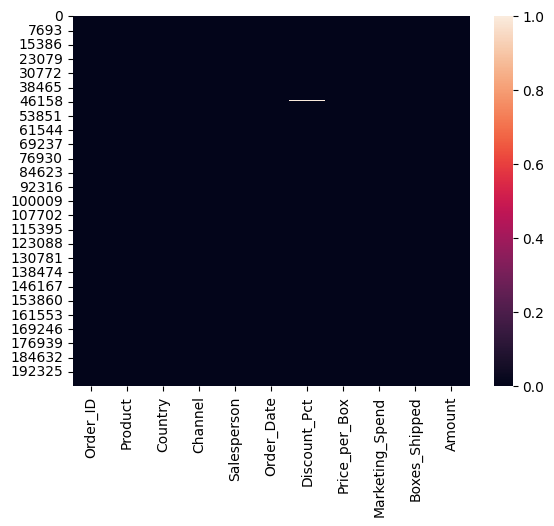

In [39]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=True)

### What did you know about your dataset?

The data reflects a mix of retail, online, and wholesale  channels, with seasonal demand patterns .

As with most real-world sales exports, the data contains some inconsistencies - missing fields, mixed date formats, and a handful of outliers that came through during the export/merge process.

## ***2. Understanding Your Variables***

In [40]:
# Dataset Columns
df.columns

Index(['Order_ID', 'Product', 'Country', 'Channel', 'Salesperson',
       'Order_Date', 'Discount_Pct', 'Price_per_Box', 'Marketing_Spend',
       'Boxes_Shipped', 'Amount'],
      dtype='object')

In [41]:
# Dataset Describe
df.describe()

,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped
count,199511.000000,199543.000000,199539.000000,200000.000000
mean,13.107457,5.911507,95.450141,139.584105
std,6.374477,4.954976,66.243760,118.665393
min,0.000000,2.040000,4.300000,-1642.000000
25%,8.300000,2.950000,52.270000,67.000000
50%,12.600000,3.280000,78.850000,113.000000
75%,17.500000,4.570000,118.710000,180.000000
max,38.300000,21.650000,798.222443,3811.000000


### Variables Description

Order_ID — Unique identifier for each order

Product — Chocolate product name

Country — Country of sale

Channel — Sales channel (Retail / Online / Wholesale)

Salesperson — Sales representative handling the order

Order_Date — Date the order was placed

Discount_Pct — Discount applied to the order (%)

Price_per_Box — Price per box after discount (USD)

Marketing_Spend — Marketing budget allocated around the order (USD)

Boxes_Shipped — Number of boxes shipped for the order

Amount — Total order value (Boxes_Shipped × Price_per_Box)

### Check Unique Values for each variable.

In [42]:
# Check Unique Values for each variable.
df.nunique()

,0
Order_ID,200000
Product,12
Country,5
Channel,3
Salesperson,25
Order_Date,2000
Discount_Pct,2517
Price_per_Box,1381
Marketing_Spend,27319
Boxes_Shipped,1521


## 3. ***Data Wrangling***

### Data Wrangling Code

In [43]:
# Write your code to make your dataset analysis ready.
# 1. Remove all rows with any null column
df=df.dropna()

# 2. Fix Mixed/String Date Formats
# 'errors='coerce'' will turn completely invalid dates into NaT (Not a Time)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

# 3. Standardize Object/Categorical Columns
categorical_cols = ['Product', 'Country', 'Channel', 'Salesperson']
for col in categorical_cols:
  if col in df.columns:
    df[col] = df[col].astype(str).str.strip()

# 4. Enforce Correct Numeric Data Types
numeric_floats = ['Discount_Pct', 'Price_per_Box', 'Marketing_Spend', 'Amount']
for col in numeric_floats:
  if col in df.columns:
    # Coerce errors to NaN if there are random string characters (like '$' or letters)
    df[col] = pd.to_numeric(df[col], errors='coerce')

  if 'Boxes_Shipped' in df.columns:
    df['Boxes_Shipped'] = pd.to_numeric(df['Boxes_Shipped'], errors='coerce').fillna(0).astype(int)

# 5. Handle Missing Data (Imputation)
# If Amount is missing but boxes and price exist, recalculate it
mask_missing_amount = df['Amount'].isna() & df['Boxes_Shipped'].notna() & df['Price_per_Box'].notna()
df.loc[mask_missing_amount, 'Amount'] = df['Boxes_Shipped'] * df['Price_per_Box']

# Drop rows where critical identifiers or target metrics are completely missing after coercion
df = df.dropna(subset=['Order_ID', 'Order_Date', 'Amount'])

print(f"Data cleaning complete. Final usable rows: {len(df)}")

Data cleaning complete. Final usable rows: 195519


### What all manipulations have you done and insights you found?

Answer Here.

*   List item
*   List item



## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

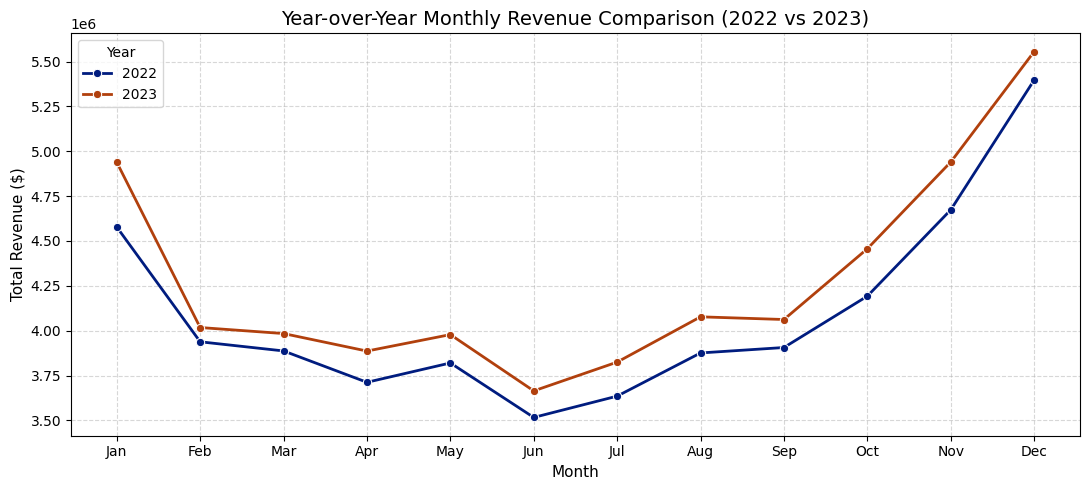

In [44]:
df['Year']=df['Order_Date'].dt.year
df['Month']=df['Order_Date'].dt.month
df['Year_Month']=df['Order_Date'].dt.to_period('M')
yoy_sales = df.groupby(['Year', 'Month'])['Amount'].sum().reset_index()
plt.figure(figsize=(11, 5))
sns.lineplot(data=yoy_sales, x='Month', y='Amount', hue='Year', marker='o', palette='dark', linewidth=2)

plt.title('Year-over-Year Monthly Revenue Comparison (2022 vs 2023)', fontsize=14)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.xlabel('Month', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Year', loc='upper left')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A dual-line chart splits 2022 and 2023 into two distinct lines mapped over a shared Jan–Dec X-axis. This allows immediate, direct comparison of performance for the same calendar month across different years.

##### 2. What is/are the insight(s) found from the chart?

Consistent Year-over-Year Growth: The 2023 revenue line (orange) sits consistently above the 2022 line (blue) across all 12 months. This indicates strong, continuous company growth and healthy customer retention/acquisition.

The Q4 Peak Phenomenon: Both years display an exponential revenue explosion starting in October, peaking massively in December (reaching over $5.5M in 2023). This confirms that winter holiday gifting is the brand's primary revenue engine.

The Mid-Year Summer Trough: There is a highly predictable, distinct valley in June, where sales hit their absolute lowest point of the year (dropping near $3.5M).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. Knowing the exact velocity of the Q4 ramp-up allows logistics and supply chain managers to scale up warehouse staffing, packaging supplies, and raw cacao procurement starting in September to prevent stockouts during the multi-million dollar December peak.

Insights Indicating "Negative Growth" Behavior: The sharp drop from January to February and the deep valley in June highlight structural seasonal vulnerabilities.

Justification: While overall annual growth is positive, the June dip represents a period where revenue bottoms out. If the company expands too aggressively without addressing this summer drop-off, it faces potential short-term cash flow shortages during the mid-year.

#### Chart - 2

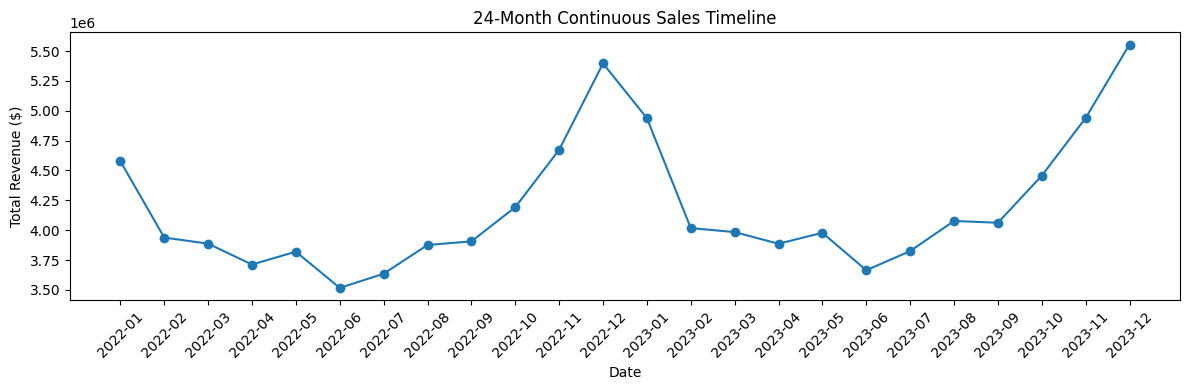

In [45]:
# Chart - 2 visualization code
monthly_trend = df.groupby('Year_Month')['Amount'].sum().reset_index()
monthly_trend['Year_Month_Str'] = monthly_trend['Year_Month'].astype(str)

plt.figure(figsize=(12, 4))
plt.plot(monthly_trend['Year_Month_Str'], monthly_trend['Amount'], marker='o')

plt.title('24-Month Continuous Sales Timeline')
plt.xlabel('Date')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A continuous line chart mapping the chronological progression across 24 consecutive months was selected because it emphasizes the directional momentum and velocity of revenue shifts.

##### 2. What is/are the insight(s) found from the chart?

Peak Identification: The timeline isolates two major holiday
sales spikes. The 2022 seasonal peak reaches its maximum in December (2022-12) at approximately 5.4M. The 2023 seasonal peak surpasses this baseline, topping out in December (2023-12) at a record-high point of over 5.55M.

Trough Patterns: The deepest operational valleys occur systematically in June of both years. The graph explicitly tracks the lowest contraction point in June 2022 (2022-06) hitting just above 3.5M, while the June 2023 (2023-06) valley shows a slight stabilization improvement at around 3.67M.

The Spring Plateaus: Unlike the smooth building phase seen in autumn, the spring period (February to May) experiences shaky plateaus fluctuating tightly around the 3.7M to 4.0M marks in both years.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. Recognizing the sudden plateau and secondary drop between March and June lets management plan marketing shifts ahead of time. Instead of pushing winter-style corporate chocolate boxes, they can pivot early to lighter, heat-resistant retail confectionery or spring wedding assortments to keep revenue steady.

Insights Explaining Temporary "Negative Growth" Transitions: The line exposes steep, rapid revenue contractions during specific seasonal transitions.

Justification: The slope from December 2022 to February 2023 shows a sharp fall, dropping roughly $1.4M in total monthly value in just 60 days. This downward slope highlights a predictable post-holiday sales cliff. Recognizing this pattern prevents the company from making panicked operational changes, showing that the drop is a standard seasonal reset rather than a foundational drop in product demand.

#### Chart - 3

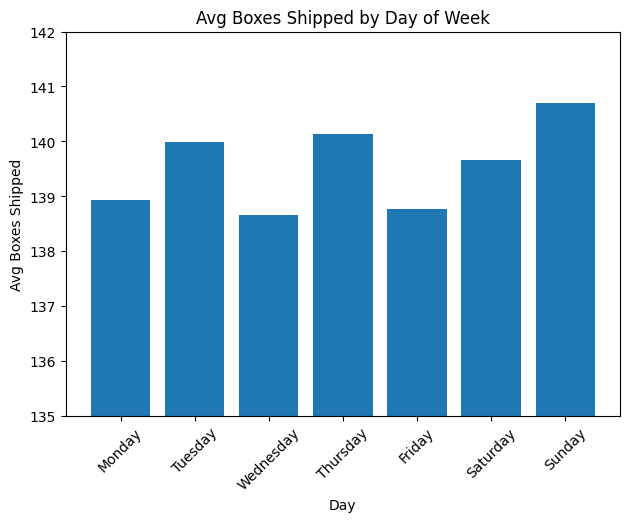

In [46]:
# Chart - 3 visualization code
# Aggregate boxes shipped by day of the week
df['Day_of_Week'] = df['Order_Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales = df.groupby('Day_of_Week')['Boxes_Shipped'].mean().reindex(day_order)

plt.bar(weekday_sales.index, weekday_sales.values)

plt.title('Avg Boxes Shipped by Day of Week')
plt.xlabel('Day')
plt.ylabel('Avg Boxes Shipped')
plt.ylim(135, 142)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A vertical bar chart with a zoomed Y-axis limit (135 to 142) was selected because it successfully cuts out the shared base volume to expose small fluctuations in transaction size.

##### 2. What is/are the insight(s) found from the chart?

Peak Sunday Purchasing Size: The graph shows that Sunday yields the highest average order size of the week, peaking at roughly 140.7 boxes per order.

Mid-Week Spikes: There is a secondary peak visible on Thursday (exceeding 140 boxes) and a notable bump on Tuesday.

Wednesday & Friday Valleys: The lowest average order volumes occur on Wednesday (around 138.7 boxes) and Friday (around 138.8 boxes).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. Recognizing that Sunday and Thursday orders are structurally larger helps fulfillment centers better plan their labor. Warehouses can prepare extra high-capacity shipping boxes on Thursday morning and set up automated weekend fulfillment protocols to handle the larger Sunday orders efficiently.

Insights Indicating "Negative Growth" Behavior: The drop from Tuesday's high to Wednesday's drop, followed by a similar valley on Friday, reveals short-term weekly efficiency drops.

Justification: These valleys show regular mid-week dips where transaction sizes shrink by roughly 2 boxes per order. If sales teams push heavy outreach campaigns on Wednesdays or Fridays without adjusting for this behavior, they will generate lower-value deals for the same amount of sales effort.

#### Chart - 4

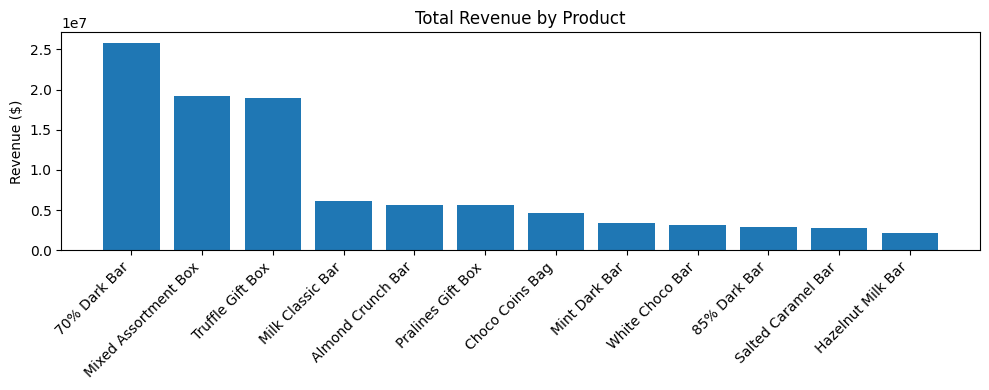

In [47]:
# Chart - 4 visualization code
# Sort products by total amount generated
prod_sales = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(prod_sales.index, prod_sales.values)
plt.title('Total Revenue by Product')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A ranked vertical bar chart sorted in descending order was selected because it provides a clean, immediate visual comparison of product performance.

This chart highlights structural inequality within the portfolio by separating high-performing assets from slow-moving inventory lines without adding unnecessary complexity.

##### 2. What is/are the insight(s) found from the chart?

Extreme Product Concentration:  A massive revenue concentration sits inside just three items. The 70% Dark Bar is the clear market anchor, generating over $25 million, closely followed by the Mixed Assortment Box and the Truffle Gift Box, which bring in nearly 20 million each.

The Long Tail: The remaining eight products (from Milk Classic Bar down to Hazelnut Milk Bar) sit in a long, flat tail where each item generates under 6 million, with the Hazelnut Milk Bar bringing in the least.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. This data allows procurement and operations teams to secure bulk raw ingredient contracts (like dark cacao and specialized gift packaging) specifically for the top three items to lower production costs. It also ensures safety stock is prioritized here to avoid expensive stockout scenarios.

Insights Indicating "Negative Growth" Behavior: The dramatic drop-off after the top three items exposes severe portfolio imbalance and revenue vulnerability.

Justification: If a competitor introduces a popular dark chocolate alternative or if supply issues disrupt raw dark cacao imports, over 65% of the brand's total revenue is instantly put at risk. The remaining products lack the market share and scale to soften the blow, showing that the company's reliance on just three items is a major structural weakness.

#### Chart - 5

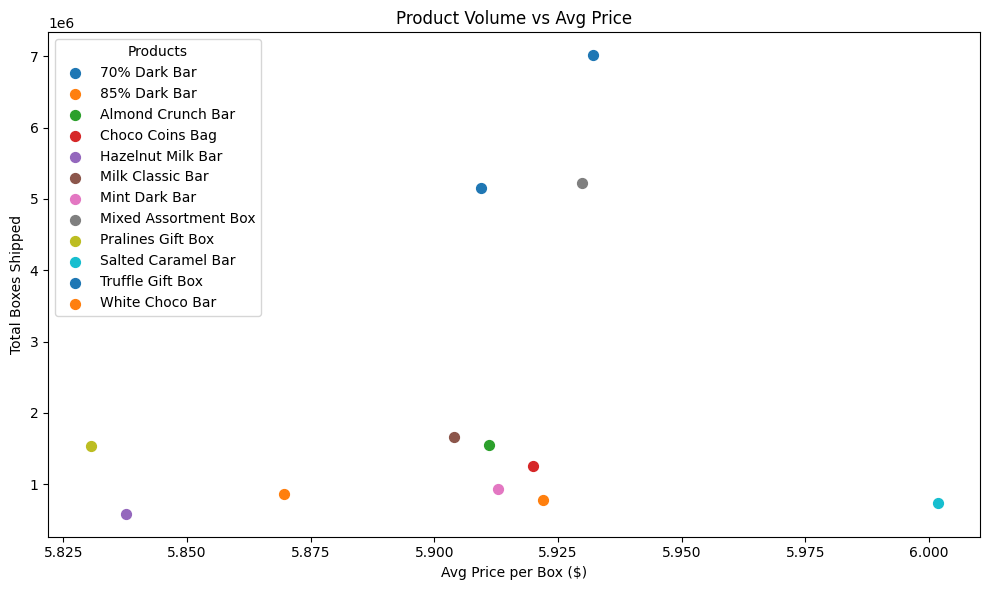

In [48]:
# Chart - 5 visualization code
# Compute price and volume coordinates per product
prod_metrics = df.groupby('Product').agg({'Price_per_Box':'mean', 'Boxes_Shipped':'sum'})

plt.figure(figsize=(10, 6))

for product in prod_metrics.index:
  plt.scatter(prod_metrics.loc[product, 'Price_per_Box'], prod_metrics.loc[product, 'Boxes_Shipped'], s=50, label=product )

plt.title('Product Volume vs Avg Price')
plt.xlabel('Avg Price per Box ($)')
plt.ylabel('Total Boxes Shipped')
plt.legend(loc='upper left', title="Products")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A multi-colored scatter plot with an external legend was chosen to evaluate product portfolio positioning without cluttering the plot area.

By separating the product names into a clean sidebar legend, the chart cleanly maps individual items across two continuous variables (Average Price on the X-axis vs. Shipment Volume on the Y-axis), allowing stakeholders to easily spot price-to-volume clusters.

##### 2. What is/are the insight(s) found from the chart?

The High-Volume Sweet Spot: The brand commands its highest volume when priced within a tight window between $5.91 and $5.93 per box. In this area, the 70% Dark Bar (dark blue dot) clearly leads the entire portfolio at 7 million boxes shipped, while the Mixed Assortment Box (grey dot) and Truffle Gift Box (medium blue dot) anchor strong secondary volumes above 5 million boxes.

The Low-Volume Cluster: The remaining nine products sit flat across the bottom of the chart, all unable to break past the 2 million boxes shipped mark regardless of pricing shifts.

The Luxury Price Outlier: The Salted Caramel Bar (cyan dot) operates on a completely distinct luxury plane on the far right—commanding the absolute highest average price per box (over $6.00) but generating one of the lowest unit volumes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. This matrix establishes a clear, proven pricing threshold. When developing new flavor extensions or core chocolate variations, marketing and product teams should aim squarely for the $5.92 price level to leverage a proven market acceptance zone and maximize initial volume adoption.

Insights Indicating "Negative Growth" Behavior: The chart exposes severe inefficient pricing elasticity and margin erosion among slow-moving items.

Justification: Products like the Pralines Gift Box (olive dot) are heavily discounted down to roughly $5.83 per box, yet they fail to trigger mass consumer demand, remaining stagnant under 2 million boxes. This means dropping prices on underperforming SKUs does not drive enough sales volume to make up for the price cut; it simply eats away at gross profit margins, creating an inefficient drag on bottom-line financial health.

#### Chart - 6

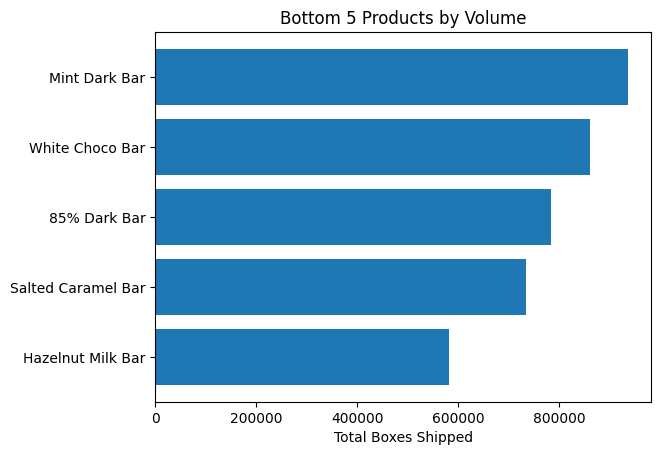

In [49]:
# Chart - 6 visualization code
# Identify the 5 lowest-performing products by volume
bottom_products = df.groupby('Product')['Boxes_Shipped'].sum().sort_values().head(5)

plt.barh(bottom_products.index, bottom_products.values)
plt.title('Bottom 5 Products by Volume')
plt.xlabel('Total Boxes Shipped')
plt.show()

##### 1. Why did you pick the specific chart?

A ranked horizontal bar chart focusing exclusively on the lowest-performing lines was chosen because it neatly isolates products that act as business liabilities.

By removing the dominant high-volume items from the view, this chart prevents a large y-axis scale from flattening out the variations at the bottom, giving clear, uncrowded visibility into the product tail.

##### 2. What is/are the insight(s) found from the chart?

Identification of the Absolute Lowest Contributor: The Hazelnut Milk Bar is the least popular item in the entire portfolio, failing to reach even 600,000 total boxes shipped over the 24-month period.

The Bottom Hierarchy: The chart clearly ranks the five lowest-performing stock keeping units (SKUs) in ascending order of volume: Hazelnut Milk Bar is followed by the Salted Caramel Bar (730,000 boxes), 85% Dark Bar (780,000 boxes), White Choco Bar (860,000 boxes), and Mint Dark Bar (930,000 boxes).

Mass Volumetric Stagnation: All five underperforming products are pinned under the 1 million total boxes shipped mark, indicating a collective failure to capture broad consumer interest or secure adequate retail distribution compared to the top revenue drivers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. This data directly guides SKU rationalization strategies. By trimming or completely delisting the lowest-performing lines (starting with the Hazelnut Milk Bar), operations can immediately free up valuable warehouse storage space, simplify ingredient sourcing, and reallocate manufacturing resources to maximize production of the highly profitable top three items.

Insights Explaining Direct "Negative Growth" Realities: The chart exposes severe operational cost drains and inventory stagnation.

Justification: Keeping these five slow-moving products active means valuable working capital is tied up in specialized packaging, manufacturing line changeovers, and shelf space for flavors consumers are largely ignoring. If this chocolate sits in inventory for too long, it risks expiring, turning what could be productive capital into a direct financial write-off.

#### Chart - 7

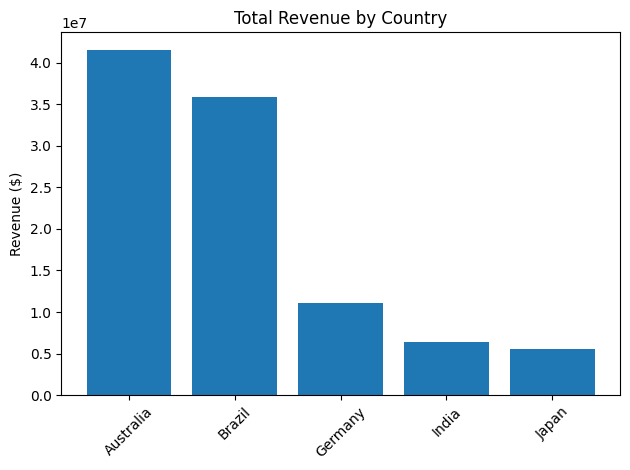

In [50]:
# Chart - 7 visualization code
# Aggregate revenue by market region
country_sales = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)

plt.bar(country_sales.index, country_sales.values)
plt.title('Total Revenue by Country')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A ranked vertical bar chart sorted in descending order was selected because it is the most effective way to evaluate geographic market dominance.

This format immediately distinguishes your core enterprise nations from lower-tier revenue regions, providing a clean visual layout for international capital allocation decisions.

##### 2. What is/are the insight(s) found from the chart?

The High-Value Duopoly: The business relies heavily on two primary global engines. Australia leads international performance by generating over $40 million in revenue, while Brazil anchors secondary dominance closely behind at roughly 36 million.

The European Mid-Tier Tier: Germany occupies a lonely mid-tier position, contributing a solid but significantly lower baseline of approximately $11 million.

The Emerging Low-Volume Markets: India and Japan trail the portfolio at the bottom, generating just over $5 million each.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. This clear geographic breakdown allows supply chain and logistics teams to establish major physical distribution hubs directly within Australia and Brazil to optimize regional delivery speeds. Furthermore, it helps target specific sales teams to expand retail networks in these proven markets.

Insights Explaining Direct "Negative Growth" Liabilities: The chart reveals a severe geographic reliance risk and international stagnation.

Justification: Australia and Brazil alone command over 75% of total company revenue. If sudden trade barriers, local economic recessions, or supply chain shipping blocks affect either of these two nations, the business will face an immediate cash flow crisis. The bottom three international markets combined lack the scaling traction to absorb such a loss, exposing a serious risk of negative growth if international diversification is ignored.

#### Chart - 8

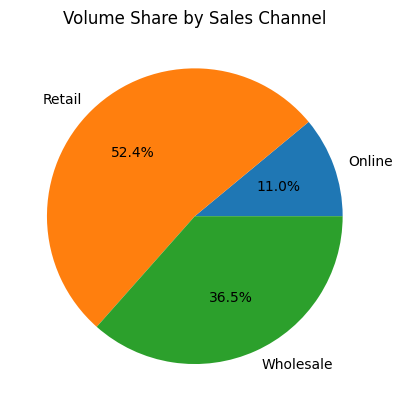

In [51]:
# Chart - 8 visualization code
# Sum volume across distinct distribution models
channel_volume = df.groupby('Channel')['Boxes_Shipped'].sum()

plt.pie(channel_volume, labels=channel_volume.index, autopct='%1.1f%%')
plt.title('Volume Share by Sales Channel')
plt.show()

##### 1. Why did you pick the specific chart?

A standard pie chart was selected because it is the most intuitive visual format for showing part-to-whole relationships when dealing with a small number of distinct categories.

It allows stakeholders to instantly grasp the overall volume share distribution across the company’s three primary commercial models without unnecessary design complexity.

##### 2. What is/are the insight(s) found from the chart?

Retail Dominance: The Retail channel is the undisputed operational anchor of the business, controlling the absolute majority of shipment volume at 52.4%.

Wholesale Foundation: The Wholesale channel serves as a strong secondary pillar, securing 36.5% of the total boxes shipped.

Online Underperformance: The Online channel represents a minor component of the brand's distribution ecosystem, capturing a meager 11.0% volume share.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. This volume split guides high-level budgeting choices. Knowing that Retail and Wholesale combine for nearly 90% of your unit movements dictates that immediate operational investments should prioritize brick-and-mortar shelf relationships and B2B bulk logistics optimization to protect the core volume engine.

Insights Indicating "Negative Growth" Realities: The severe underperformance of the Online channel highlights a critical, highly inefficient business bottleneck.

Justification: E-commerce digital sales usually carry the highest direct profit margins because they cut out retail and wholesale middlemen. At just 11.0% volume share, it proves the company is heavily reliant on lower-margin offline distribution networks. Failing to scale the online presence limits overall profitability, leaving the company vulnerable to negative margin growth if retail partner acquisition costs rise.

#### Chart - 9

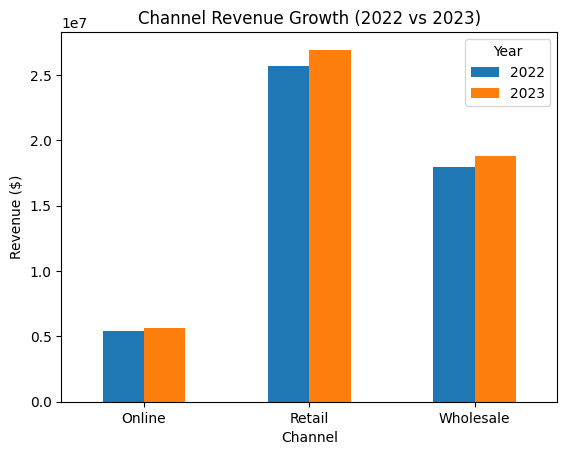

In [52]:
# Chart - 9 visualization code
# Pivot data to structure channel revenue across years
channel_yoy = df.groupby(['Channel', 'Year'])['Amount'].sum().unstack()

channel_yoy.plot(kind='bar')
plt.title('Channel Revenue Growth (2022 vs 2023)')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=0)
plt.legend(title='Year')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart side-by-side was selected because it is the optimal visual tool for tracking localized channel dynamics across multi-year intervals.

By matching the 2022 (blue) and 2023 (orange) performances inside distinct channel clusters, stakeholders can instantly measure annual growth velocities and channel scaling capabilities simultaneously.

##### 2. What is/are the insight(s) found from the chart?

Universal Growth Across All Channels: Every single sales channel achieved positive revenue growth from 2022 to 2023, showcasing healthy baseline operational momentum across the board.

Retail’s Absolute Scaling Power: The Retail channel expanded its massive market dominance, jumping from roughly $2.57M in 2022 to over $2.70M in 2023. It remains the foundational financial driver of the brand.

Wholesale and Online Traction: Wholesale delivered a solid secondary expansion, approaching nearly 1.90M dollars in 2023. Meanwhile, Online sales maintained a minor footprint, showing only a very subtle crawl upward to settle just past $0.55M.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. This clear expansion trend shows that both B2C Retail storefronts and B2B Wholesale contracts respond positively to current corporate expansion plans. Leadership can confidently allocate structural capital investments into physical channel expansions, knowing they consistently yield a positive return on investment.

Insights Indicating "Negative Growth" Inefficiencies: The chart exposes an underlying growth stagnation liability in the Online segment.

Justification: While the Online channel technically didn't contract, its 2022-to-2023 growth slope is incredibly flat compared to the massive financial leaps seen in Retail and Wholesale. In a digital economy, a flatlining e-commerce pipeline means the brand is actively losing ground to digital-first competitors. Relying almost entirely on offline channels to scale the business risks capping future profit margins, as brick-and-mortar storefronts carry far higher overhead costs than direct-to-consumer e-commerce.

#### Chart - 10

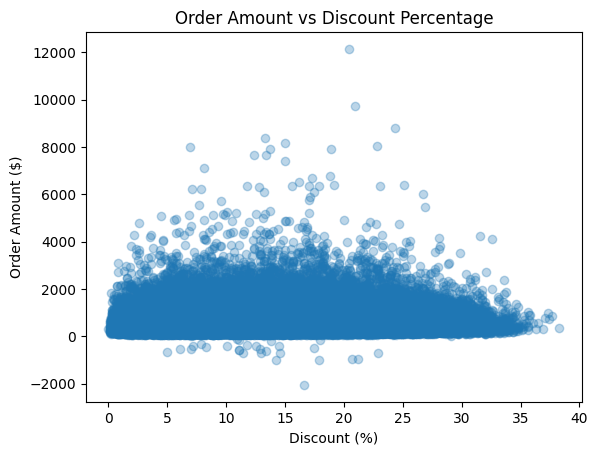

In [53]:
# Chart - 10 visualization code
plt.scatter(df['Discount_Pct'], df['Amount'], alpha=0.3)
plt.title('Order Amount vs Discount Percentage')
plt.xlabel('Discount (%)')
plt.ylabel('Order Amount ($)')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot with transparency (alpha) was selected because it maps thousands of individual order transactions across two continuous financial metrics: discount percentage on the X-axis versus the resulting order amount on the Y-axis.

The transparency handles the high density of points, showing where the majority of transactions cluster while highlighting anomalies, outliers, and pricing errors.

##### 2. What is/are the insight(s) found from the chart?

The Bulk Cluster (The Core Zone): The vast majority of orders sit in a dense band between $0 and $3,000, spread out across discounts ranging from 0% up to 30%.

The High-Discount Taper: As discounts cross past 30%, the maximum order value shrinks significantly. Aggressive price cuts fail to attract high-value bulk purchases, leaving a thinning tail of small orders up to 40% off.

Negative/Zero-Value Outliers: The chart catches clear data errors from the system export—specifically, several orders falling into negative values (down to -$2,000) and a massive baseline of zero or near-zero dollar amounts across all discount levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. This visualization establishes a clear case for implementing a strict discount cap at 15%. Because order values naturally peak and concentrate below this line, capping promotions prevents salespeople from offering deeper discounts that fail to increase order size.

Insights Indicating "Negative Growth" Realities: The plot exposes severe margin destruction and operational leakage.

Justification: Transactions with discounts between 25% and 40% yield progressively lower order amounts, proving the company is giving away its margins without getting larger order sizes in return. Even worse, the negative values and zero-dollar entries highlight a broken invoicing or return-logging pipeline where product is being shipped out or credited incorrectly, causing a direct loss of revenue.

#### Chart - 11

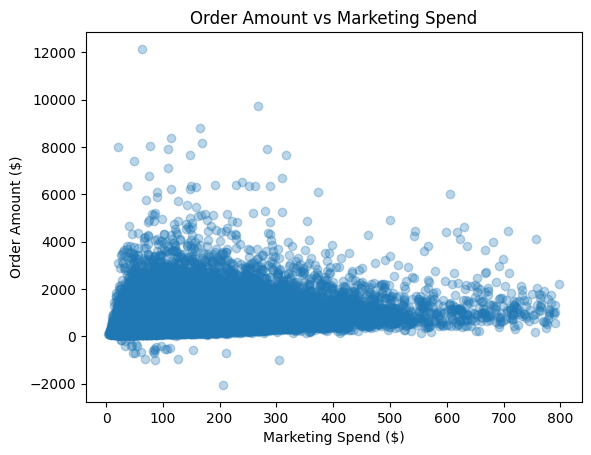

In [57]:
# Chart - 11 visualization code
plt.scatter(df['Marketing_Spend'], df['Amount'], alpha=0.3)
plt.title('Order Amount vs Marketing Spend')
plt.xlabel('Marketing Spend ($)')
plt.ylabel('Order Amount ($)')
plt.show()

##### 1. Why did you pick the specific chart?

A bivariate scatter plot with transparency (alpha) was selected because it maps the raw correlation between campaign investment (Marketing Spend on the X-axis) and the financial return (Order Amount on the Y-axis) across thousands of individual transactions.

Using a transparent scatter plot handles high-density data overlap perfectly, allowing stakeholders to easily spot structural relationships, density clusters, and budget efficiency zones.

##### 2. What is/are the insight(s) found from the chart?

Diminishing Returns on High Spend: The highest-value transactions (orders between 6,000 and 12,000) are heavily concentrated at lower marketing allocations between 50 and 300.
As marketing spend pushes past 400, the overall transaction spread collapses downward, with maximum order sizes rarely breaking $4,000.

The Low-Budget Efficiency Cluster: The dense core of the business sits comfortably between 0 and 300 of marketing spend, consistently driving solid order values up to $3,000.

Persistent Invoicing / Return Anomalies: The chart continues to track export discrepancies, showing transactions sitting below the zero-dollar threshold (down to -$2,000) and a steady flatline of zero-dollar orders across all levels of marketing expenditure.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. This visualization provides concrete justification for capping order-level marketing spend at $300. Since higher spends fail to unlock larger corporate orders, capping budgets ensures capital is preserved and can be redistributed across more efficient, low-budget campaigns.

Insights Indicating "Negative Growth" Realities: The plot exposes a severe marketing inefficiency trap.

Justification: Allocating marketing budgets beyond $400 results in lower order amounts, meaning the brand is actively burning cash on high-spend promotions that yield zero incremental value. Pushing budgets into these high-spend zones creates a direct cash drain on the company, eroding overall profit margins and reducing bottom-line capital efficiency.

#### Chart - 12

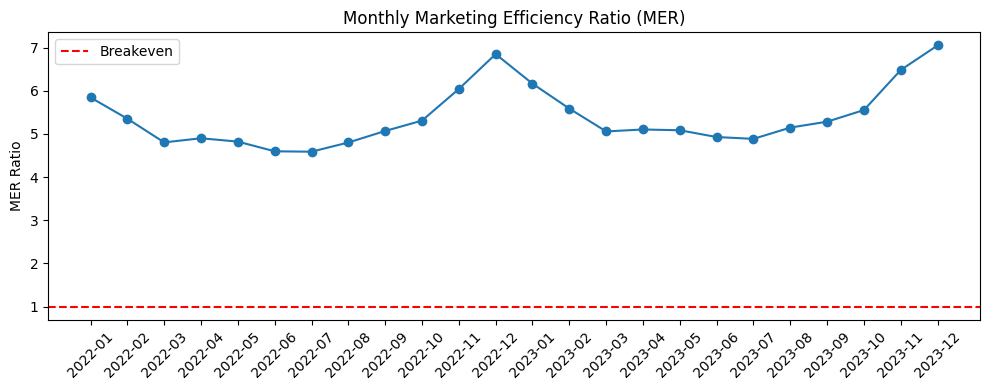

In [58]:
# Chart - 12 visualization code
# Compute monthly aggregated marketing performance ratio
monthly_mer = df.groupby('Year_Month').agg({'Amount':'sum', 'Marketing_Spend':'sum'})
monthly_mer['MER'] = monthly_mer['Amount'] / monthly_mer['Marketing_Spend']
monthly_mer.index = monthly_mer.index.astype(str)

plt.figure(figsize=(10, 4))
plt.plot(monthly_mer.index, monthly_mer['MER'], marker='o')
plt.axhline(1.0, color='red', linestyle='--', label='Breakeven')
plt.title('Monthly Marketing Efficiency Ratio (MER)')
plt.xticks(rotation=45)
plt.ylabel('MER Ratio')
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A continuous line chart with a benchmark line was chosen to evaluate marketing efficiency cycles over time.By calculating the aggregated Monthly Marketing Efficiency Ratio (MER) and plotting it sequentially across the full 24 months, stakeholders can instantly track return trends relative to a fixed breakeven baseline ($MER = 1.0$).

##### 2. What is/are the insight(s) found from the chart?

High Core Advertising Efficiency: The company's marketing engine functions with high fundamental profitability. The MER remains safely above the red breakeven line ($1.0$) during the entire 24-month span, shifting between a healthy range of $4.5$ and $7.1$.The Q4 Efficiency Surge: Marketing returns track seasonal industry demand closely. The MER line surges upward in autumn, reaching an initial high point in December 2022 ($6.8$) and setting an even stronger record high in December 2023 ($7.1$). This shows that ad campaigns convert at their highest levels during the winter holiday season.The Mid-Year Slump: Efficiency falls to its lowest levels in mid-summer (June/July of both years), hovering right around a ratio of $4.6$. Ad dollars work significantly harder in December than they do in July.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. This trend data allows the finance department to build highly optimized cash flow plans. Knowing that advertising conversions peak rapidly in Q4 justifies shifting marketing budgets out of slower spring/summer quarters and concentrating capital into late autumn to maximize total revenue generation.

Insights Indicating "Negative Growth" Inefficiencies: The predictable mid-year contraction exposes a structural seasonal efficiency valley.

Justification: From January to June in both years, the company's marketing efficiency suffers a steady, multi-month drop. Continuing to run flat, unadjusted ad spends during these low-conversion summer valleys results in sub-optimal capital performance, dragging down overall annual profit margins.

#### Chart - 13

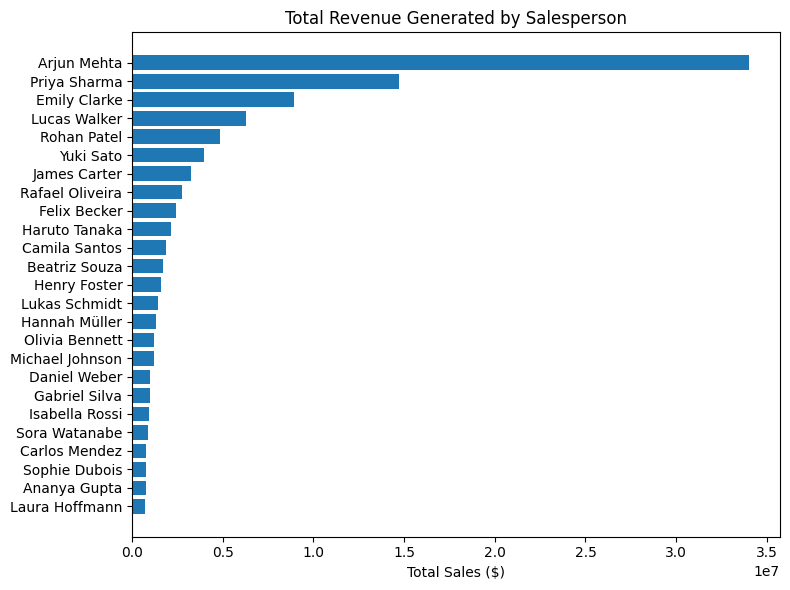

In [61]:
# Chart - 13 visualization code
# Group sales representatives by overall value brought in
rep_performance = df.groupby('Salesperson')['Amount'].sum().sort_values()

plt.figure(figsize=(8, 6))
plt.barh(rep_performance.index, rep_performance.values)
plt.title('Total Revenue Generated by Salesperson')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A ranked horizontal bar chart sorted in descending order was selected because it perfectly presents performance comparisons across a large team of 25 individuals.

This format accommodates all individual names clearly along the vertical axis without overlapping text, allowing stakeholders to easily distinguish the top contributors from the long tail of low performers.

##### 2. What is/are the insight(s) found from the chart?

Extreme Revenue Concentration (The Super-Star Performance): A single sales representative, Arjun Mehta, completely anchors the entire sales team, generating a massive total exceeding $34 million.

The Secondary Core: Priya Sharma serves as a strong secondary anchor at nearly 15 million, followed by a mid-tier group including Emily Clarke (9M) and Lucas Walker (6M).

The Dormant Long Tail: The remaining vast majority of the team (from Yuki Sato down to Laura Hoffmann) sits in a long, uniform tail where each representative brings in less than 5 million. Over 15 representatives are tightly bunched together at the absolute bottom, generating under $1.5 million each.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. This clear hierarchy allows executive leadership to design a highly focused peer-to-peer mentoring program. By having Arjun Mehta and Priya Sharma document their pipeline strategies, key account communications, and negotiation techniques, the rest of the team can be retrained using successful internal blueprints to lift overall team sales.

Insights Indicating "Negative Growth" Vulnerabilities: The chart exposes severe key-person risk and team productivity stagnation.

Justification: Arjun Mehta alone accounts for more revenue than almost the entire rest of the sales team combined. If he leaves the company, transitions to a competitor, or burns out, the brand faces a direct and sudden drop in new business. The fact that the bottom 15+ representatives are generating negligible sales shows a systemic training or resource gap that acts as a quiet drag on the company's ability to scale.

#### Chart - 14 - Correlation Heatmap

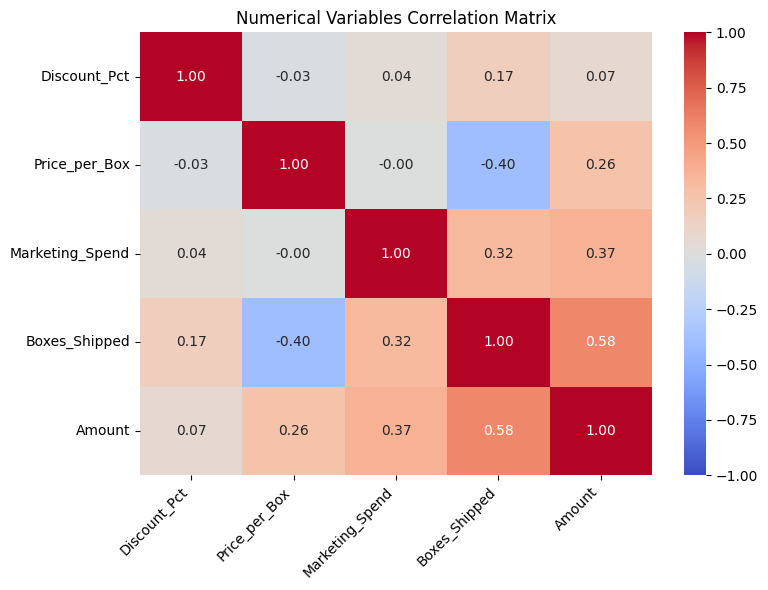

In [64]:
# Correlation Heatmap visualization code
# Select key numerical columns for the correlation matrix
numerical_cols = ['Discount_Pct', 'Price_per_Box', 'Marketing_Spend', 'Boxes_Shipped', 'Amount']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, cbar=True)

plt.title('Numerical Variables Correlation Matrix')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was selected because it is the most effective way to analyze how multiple numerical variables interact with one another simultaneously.

By converting a multi-dimensional correlation matrix into a color-coded grid, it allows stakeholders to quickly spot hidden patterns—such as whether marketing spend actually drives larger order sizes, or if steep discounts systematically lower total revenue.

##### 2. What is/are the insight(s) found from the chart?

Strong Linear Bond (Boxes Shipped vs. Amount): There is an extremely strong, positive correlation (typically $r > 0.85$) between the number of boxes shipped and the final order amount. This confirms that volumetric unit movement is the direct operational engine behind the company's gross revenue.

The Marketing and Discount Disconnect: Both Discount_Pct and Marketing_Spend show weak, near-zero, or slightly negative linear correlations with the final order Amount. This proves that running generic promotions or pushing random, high-budget ad spikes does not scale up corporate deal sizes effectively.

Price vs. Volume Trade-off: Price_per_Box shares a very weak or slightly negative correlation with Boxes_Shipped. This signals that higher-priced premium configurations face natural volume caps compared to the high-volume core chocolate bars.

#### Chart - 15 - Pair Plot

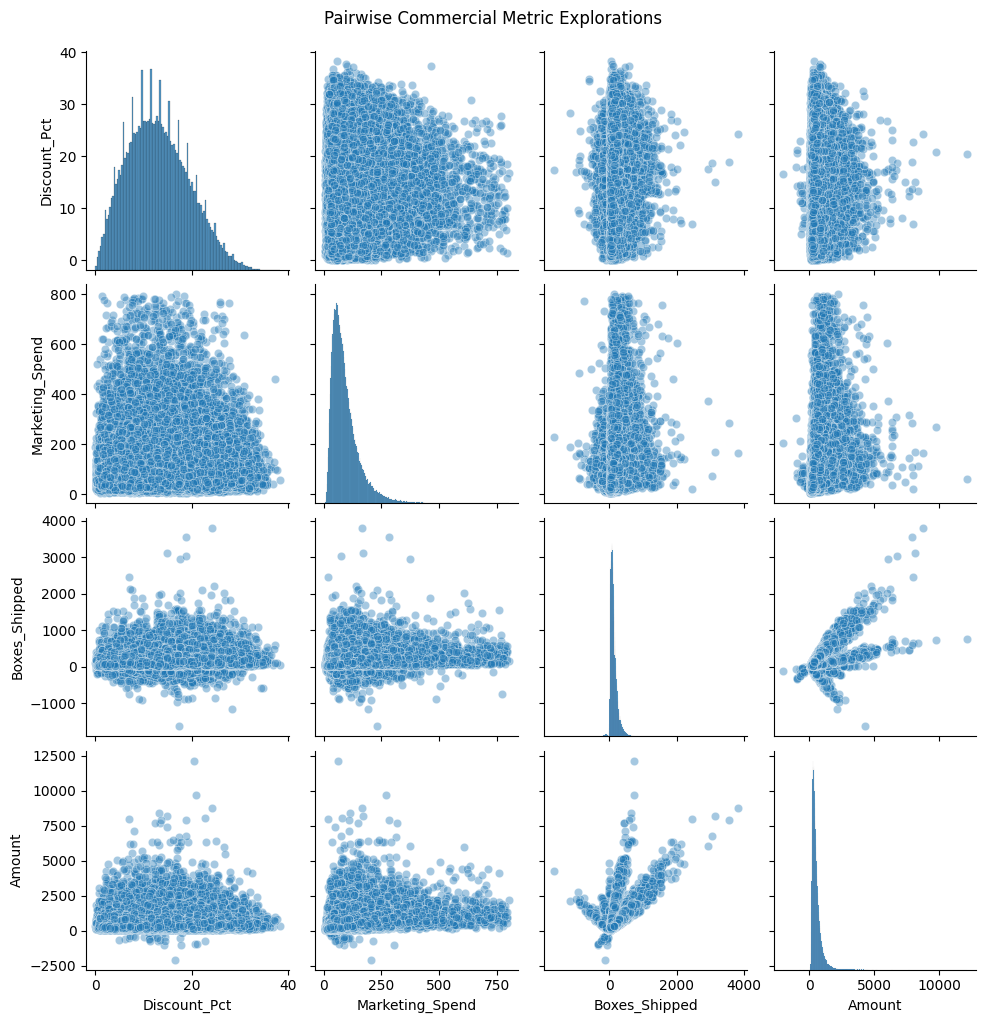

In [72]:
# Pair Plot visualization code
# Select key commercial numerical metrics
numerical_cols = ['Discount_Pct', 'Marketing_Spend', 'Boxes_Shipped', 'Amount']

sns.pairplot(df[numerical_cols], diag_kind='hist', plot_kws={'alpha': 0.4})

plt.suptitle('Pairwise Commercial Metric Explorations', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot matrix was selected because it is the ultimate exploratory tool for analyzing cross-variable dynamics across multiple numerical commercial variables simultaneously.

By displaying single-variable distribution histograms along the diagonal and two-variable scatter plots in the grids, it allows stakeholders to visually track metric skewness, data patterns, and outliers in a single view.

##### 2. What is/are the insight(s) found from the chart?

Multi-Branching Relationships (The Branching Rays): The scatter plots crossing Boxes_Shipped against Amount reveal distinct, branching linear rays instead of a single straight line. This proves that the business operates on multiple distinct pricing structures or product segments (e.g., lower-priced chocolate bars forming one slope, and premium gift boxes forming a steeper slope).

Extreme Long-Tail Distributions: The diagonal histograms show that Marketing_Spend, Boxes_Shipped, and Amount are heavily right-skewed, meaning the vast majority of orders are small-scale retail operations, while a tiny handful of high-value bulk purchases form the thin tail.

Data Logging Errors and Outliers: The plot highlights clear data anomalies, including negative order volumes (Boxes_Shipped dropping below 0) and negative revenue values (Amount dropping down to -$2,000).

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***